# Employee Attrition Prediction - Gargi Nemade 

The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on factors such as job satisfaction, monthly income, work-life balance, years at the company, and other employee-related features. The project also aims to identify the key factors influencing employee attrition and provide useful insights and recommendations for the HR department.

Task 1 — Data Loading & Exploration

In [74]:
#import necessary libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    precision_score,
    confusion_matrix,
    roc_curve,
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    auc,
    ConfusionMatrixDisplay
)

In [2]:
#import dataset and display 10 rows
df = pd.read_csv("HR_Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# dataset related information
# (rows,columns)
df.shape  

(1470, 35)

In [4]:
# dataset related information
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
# dataset related information
df.info  

<bound method DataFrame.info of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education Education

In [6]:
# Identify the target column (Attrition — Yes/No)
att_count=df["Attrition"].value_counts()
att_count

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
# Number of employees left vs stayed
stayed = att_count["No"]
left = att_count["Yes"]
print("Number of employees left: ",left)
print("Number of employees stayed: ",stayed)

Number of employees left:  237
Number of employees stayed:  1233


In [8]:
# Attrition Rate
att_rate = (left/len(df))*100
print(f"Attrition Rate = {att_rate} %")

Attrition Rate = 16.122448979591837 %


In [9]:
# How many columns are numeric vs categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical columns: ",len(num_cols))
print("Categorical columns: ",len(cat_cols))

Numerical columns:  26
Categorical columns:  9


/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_48938/1418868329.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


 The dataset is imbalanced because employees staying are much higher than employees leaving. Out of 1,470 employees, 1,233 (83.88%) stayed with the company, while only 237 (16.12%) left.

Task 2 — Data Cleaning & Preprocessing

In [10]:
# null/missing values 
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

no missing values to handles

In [11]:
# Drop columns that add no value to prediction (e.g.EmployeeNumber, Over18, StandardHours-these are constant or irrelevant)
df.drop(columns={"EmployeeNumber","Over18","StandardHours","EmployeeCount"}, inplace=True,errors="ignore")

In [12]:
# Convert the target column Attrition from Yes/No to 1/0
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
}) 

In [13]:
#Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)
df = pd.get_dummies(df, drop_first=True)

In [14]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# split dataset
X_train,X_test,y_train,y_test = train_test_split( X,y,test_size=0.2 ,random_state=42,stratify=y)

# Scale numeric features using StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Task 3 — Exploratory Data Analysis — EDA

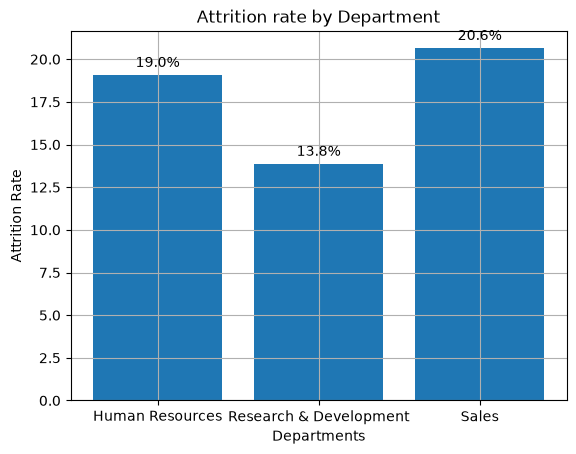

In [91]:
# Bar Graph - Attrition rate by Department
df2 = pd.read_csv("HR_Attrition.csv")
attrition_rate = (df2[df2["Attrition"] == "Yes"].groupby("Department").size()/df2.groupby("Department").size())*100
plt.grid()
plt.bar(attrition_rate.index, attrition_rate.values)

for i, value in enumerate(attrition_rate.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")
    
plt.title("Attrition rate by Department")
plt.xlabel("Departments")

plt.ylabel("Attrition Rate")
plt.savefig("Attritionrate_by_Department.png")
plt.show()

Sales has highest attrition rate i.e. 20.6% among all departments 

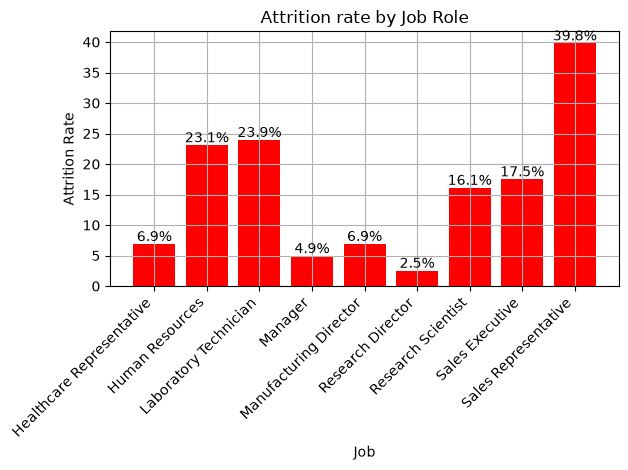

In [90]:
# Attrition rate by Job Role — which roles have the highest exit rate?
attrition_rate = (df2[df2["Attrition"] == "Yes"].groupby("JobRole").size()/df2.groupby("JobRole").size()) * 100
plt.grid()
plt.bar(attrition_rate.index, attrition_rate.values,color='red')
plt.title("Attrition rate by Job Role")
plt.xlabel("Job")
plt.ylabel("Attrition Rate")

for i, value in enumerate(attrition_rate.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")
    
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("AttritionRate_JobRole.png")
plt.show()

Sales Representative has highest exit rate of 39.8%

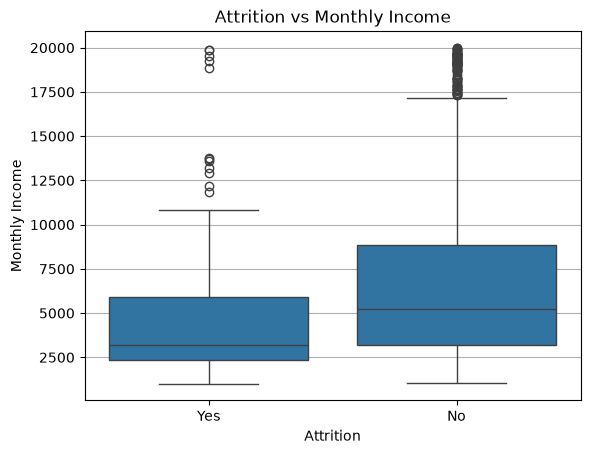

In [79]:
# Attrition vs Monthly Income — do lower paid employees leave more?
plt.grid()
sns.boxplot(data=df2, x="Attrition", y="MonthlyIncome")
plt.title("Attrition vs Monthly Income")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig("Attrition_VS_MonthlyIncome.png")
plt.show()

Employees who left the company generally have a lower median monthly income than those who stayed. However, salary alone does not explain attrition, as some higher-paid employees also left the company.

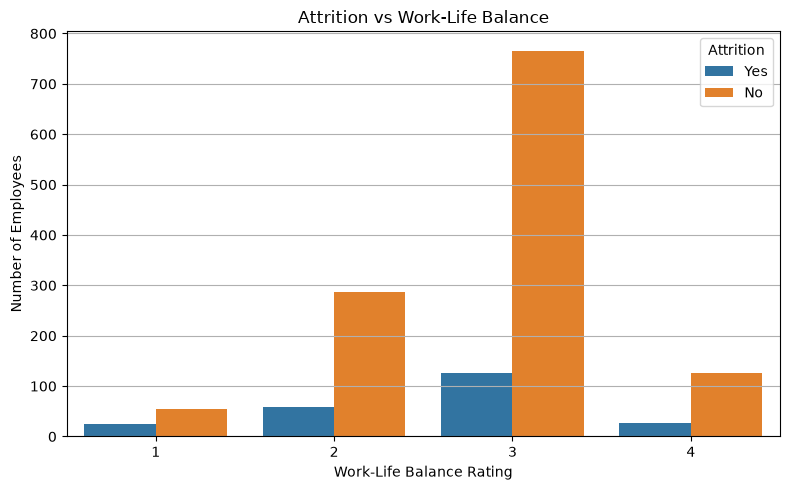

In [89]:
# Attrition vs Work-Life Balance rating — is there a visible pattern?
plt.figure(figsize=(8,5))
plt.grid()
sns.countplot(data=df2, x="WorkLifeBalance", hue="Attrition")
plt.title("Attrition vs Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("Attrition_vs_Work-LifeBalance.png")
plt.show()

Yes, there is a visible pattern. Employees with lower Work-Life Balance ratings (1 and 2) show relatively higher attrition, while employees with a rating of 4 have the lowest attrition. This suggests that a better work-life balance is associated with improved employee retention.

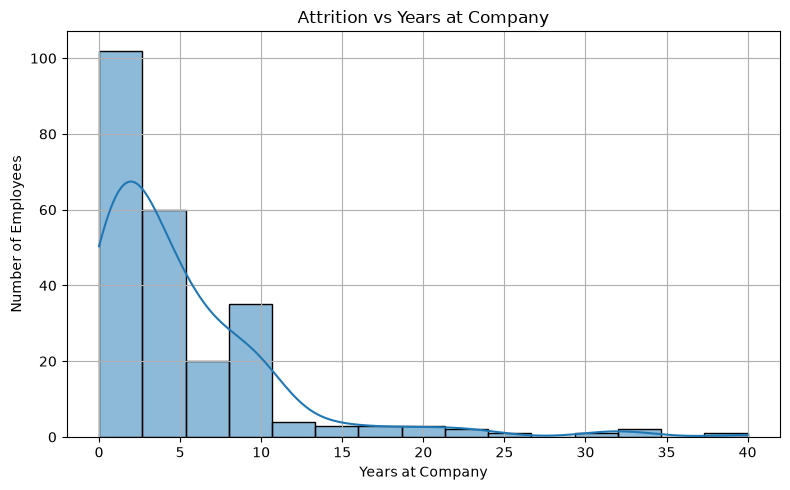

In [88]:
# Attrition vs Years at Company — at what point in tenure do employees leave most?
plt.figure(figsize=(8,5))
plt.grid()
left_emp = df2[df2["Attrition"] == "Yes"]
sns.histplot(data=left_emp,x="YearsAtCompany",bins=15,kde=True)
plt.title("Attrition vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("Attrition_vs_YearsatCompany.png")
plt.show()

Employees leave most frequently within their first 1–5 years at the company.

Insights:
1. Overall attrition is relatively low but imbalanced. Out of 1,470 employees, 237 (16.12%) left the company, while 1,233 (83.88%) stayed. This indicates that most employees remain with the organization, making attrition a minority class.
2. The Sales department experiences the highest attrition rate, followed by Human Resources, while Research & Development has the lowest attrition rate. This suggests HR should prioritize retention efforts in customer-facing departments.
3. Sales Representatives and Laboratory Technicians have the highest attrition rates among job roles, whereas Managers and Research Directors show the lowest turnover, indicating that certain roles are more prone to employee exits.
4. Employees with lower monthly incomes are more likely to leave the company. The box plot shows that employees who left generally have a lower median monthly income than those who stayed, although salary is not the only factor influencing attrition.
5. Most employees who leave do so within their first 1–5 years at the company. Attrition declines with increasing tenure, suggesting that the early years of employment are the most critical period for employee retention.

Task 4 — Model Building & Comparison

In [27]:
# Split data into training and test sets (80/20)
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [28]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# Logistic Regression

lr = LogisticRegression(class_weight="balanced",random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [30]:
# Random Forest
rf = RandomForestClassifier(class_weight="balanced",random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [31]:
# Gradient Boosting
gb = GradientBoostingClassifier( random_state=42)
gb.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [32]:
# predictions
lr_pred = lr.predict(X_test)

rf_pred = rf.predict(X_test)

gb_pred = gb.predict(X_test)


In [33]:
# compare
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.751701
1,Random Forest,0.833333
2,Gradient Boosting,0.850340


Task 5 — Model Evaluation

In [34]:
# Evaluation
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("Precision :", round(precision,3))
    print("Recall    :", round(recall,3))
    print("F1 Score  :", round(f1,3))
    print("ROC-AUC   :", round(roc,3))

    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(cm).plot()
    plt.show()

    return precision, recall, f1, roc

Precision : 0.345
Recall    : 0.617
F1 Score  : 0.443
ROC-AUC   : 0.798


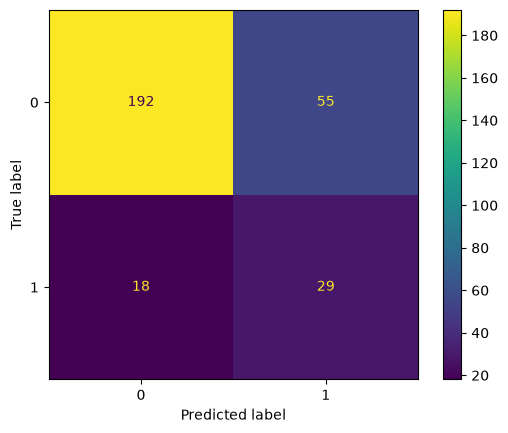

In [40]:
# logistic regression
lr_precision, lr_recall, lr_f1, lr_roc = evaluate_model(
    lr, X_test, y_test
)

Precision : 0.469
Recall    : 0.319
F1 Score  : 0.38
ROC-AUC   : 0.772


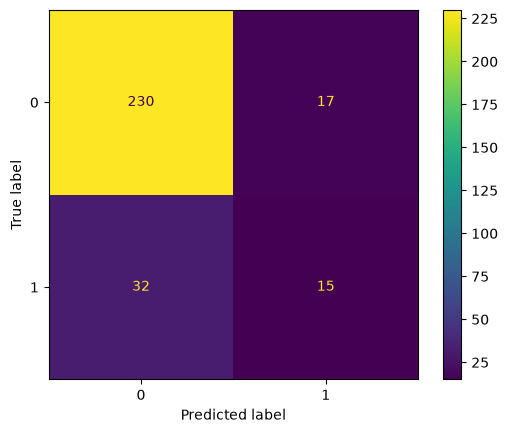

In [41]:
# random forest
rf_precision, rf_recall, rf_f1, rf_roc = evaluate_model(
    rf, X_test, y_test
)

Precision : 0.588
Recall    : 0.213
F1 Score  : 0.312
ROC-AUC   : 0.794


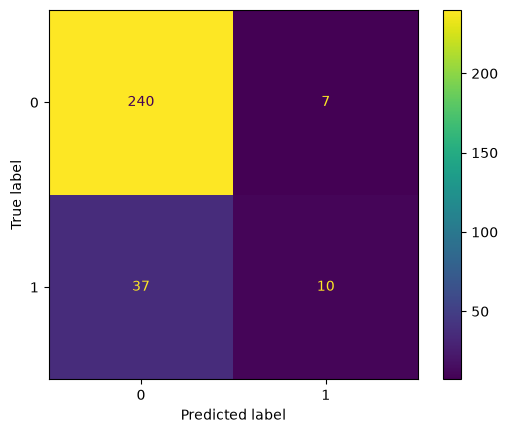

In [42]:
# Gradient boosting
gb_precision, gb_recall, gb_f1, gb_roc = evaluate_model(
    gb, X_test, y_test
)

In [43]:
# compare
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","Gradient Boosting"],
    "Precision":[lr_precision,rf_precision,gb_precision],
    "Recall":[lr_recall,rf_recall,gb_recall],
    "F1 Score":[lr_f1,rf_f1,gb_f1],
    "ROC-AUC":[lr_roc,rf_roc,gb_roc]
})

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.468750,0.319149,0.379747,0.771901
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


Logistic Regression performed the best overall. It achieved the highest ROC-AUC (0.798), Recall (0.617), and F1-score (0.443) among the three models. Although Gradient Boosting had higher precision, it missed many employees who actually left. Since identifying employees at risk is the main goal, Logistic Regression is the most suitable model.

In [44]:
# best feautures for logistic regression

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr.coef_[0])
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


In [70]:
#top 10 most important features driving employee exit
top=importance.reset_index(drop=True).head(10)
print(top)

                            Feature  Importance
0     JobRole_Laboratory Technician    0.810172
1                      OverTime_Yes    0.771095
2  BusinessTravel_Travel_Frequently    0.722538
3                 TotalWorkingYears    0.660270
4                          JobLevel    0.650173
5      JobRole_Sales Representative    0.531090
6      BusinessTravel_Travel_Rarely    0.512780
7      EducationField_Life Sciences    0.512319
8           YearsSinceLastPromotion    0.499063
9                  Department_Sales    0.470587


Task 6 — Visualization

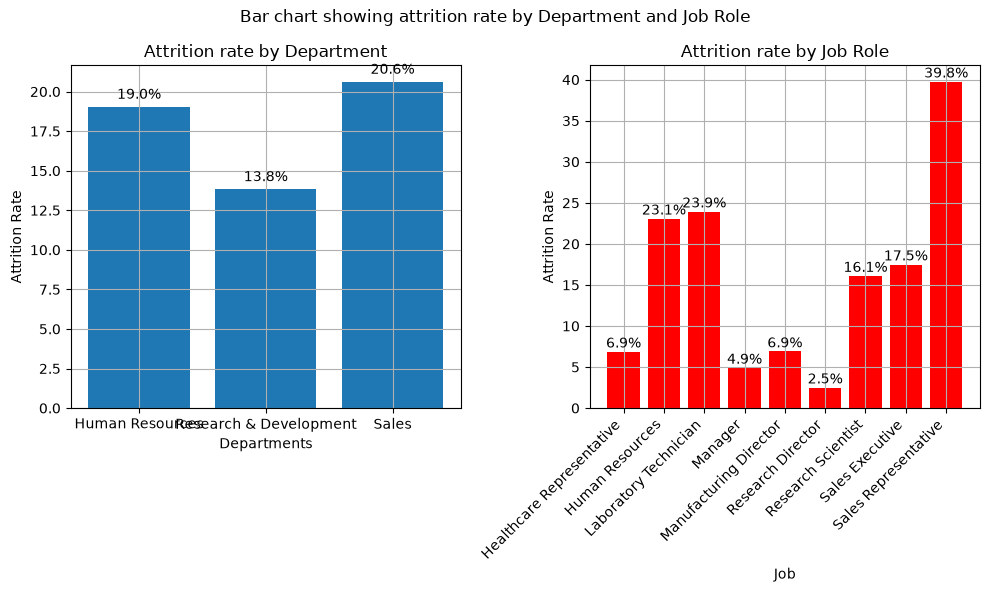

In [87]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role

plt.figure(figsize=(10,6))

# department
plt.subplot(1,2,1)
df2 = pd.read_csv("HR_Attrition.csv")
attrition_rate = (df2[df2["Attrition"] == "Yes"].groupby("Department").size()/df2.groupby("Department").size())*100
plt.bar(attrition_rate.index, attrition_rate.values)
plt.grid()

for i, value in enumerate(attrition_rate.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")
    
plt.title("Attrition rate by Department")
plt.xlabel("Departments")
plt.ylabel("Attrition Rate")

# job role
plt.subplot(1,2,2)
attrition_rate = (df2[df2["Attrition"] == "Yes"].groupby("JobRole").size()/df2.groupby("JobRole").size()) * 100
plt.grid()
plt.bar(attrition_rate.index, attrition_rate.values,color='red')
plt.title("Attrition rate by Job Role")
plt.xlabel("Job")
plt.ylabel("Attrition Rate")

for i, value in enumerate(attrition_rate.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")
    
plt.xticks(rotation=45, ha="right")

plt.suptitle("Bar chart showing attrition rate by Department and Job Role")
plt.tight_layout()

plt.savefig("Barchart_attritionrate_Department&JobRole.png")
plt.show()

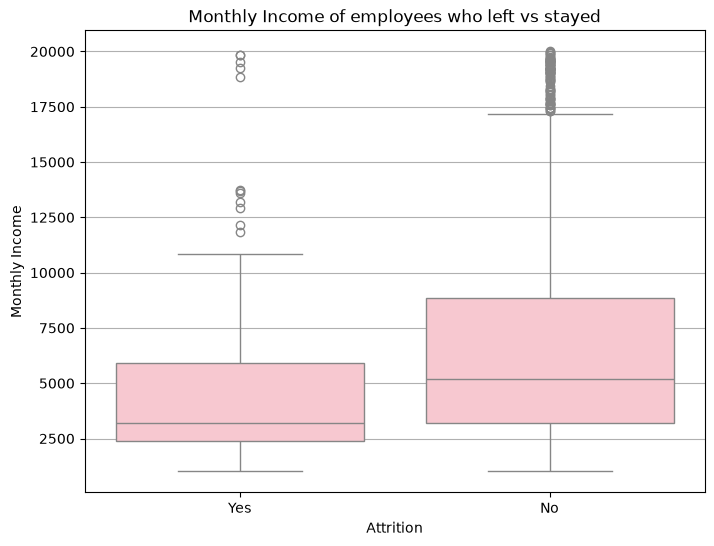

In [86]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8,6))
sns.boxplot(data=df2, x="Attrition", y="MonthlyIncome",color="pink")
plt.title("Monthly Income of employees who left vs stayed")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.grid(axis="y")
plt.savefig("monthly_income_boxplot.png")
plt.show()

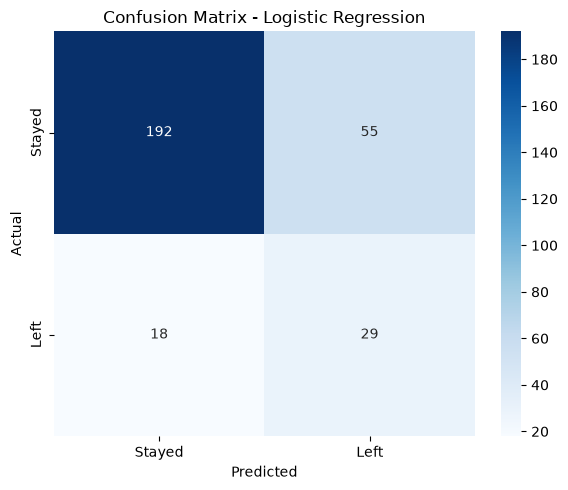

In [65]:
# Chart 3: Confusion Matrix heatmap for your best model
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True,fmt="d", cmap="Blues",xticklabels=["Stayed", "Left"],yticklabels=["Stayed", "Left"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

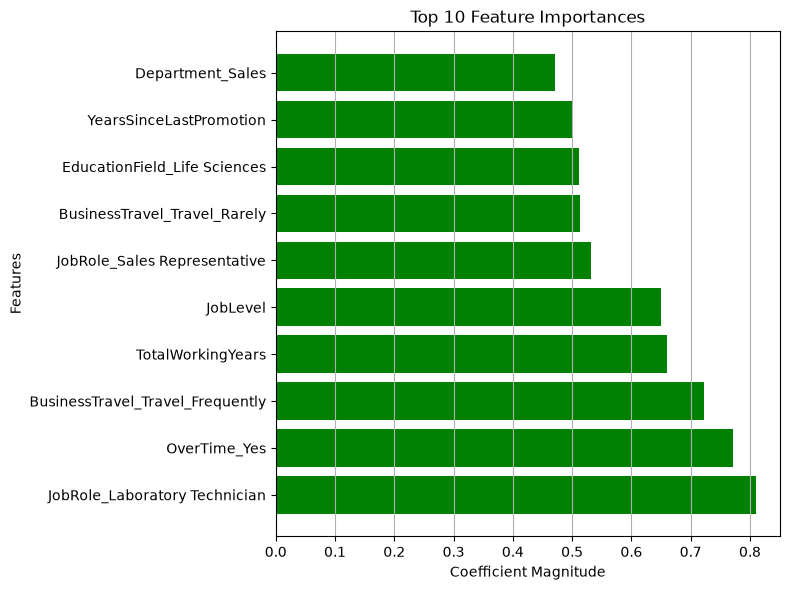

In [72]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Importance"], color="green")
plt.title("Top 10 Feature Importances")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Features")
plt.grid(axis="x")
plt.tight_layout()
plt.savefig("top10_feature_importance.png")
plt.show()

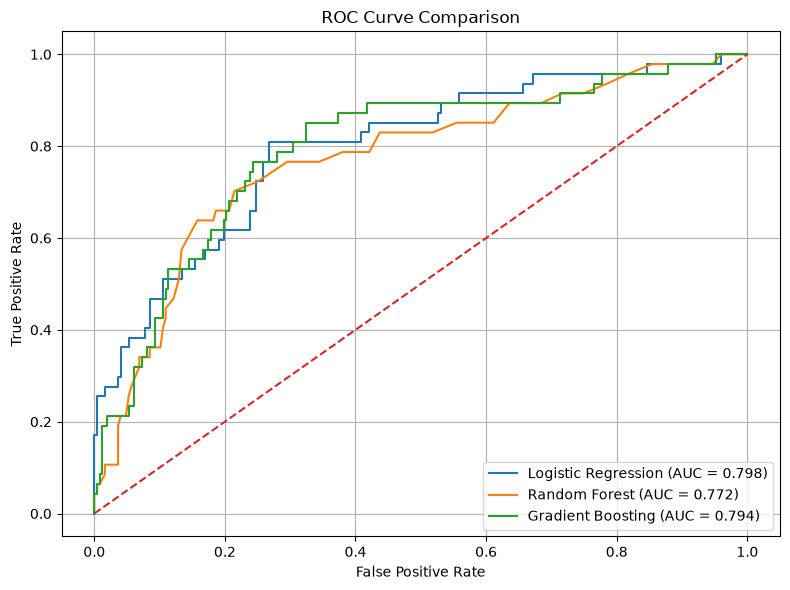

In [84]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
# Probability predictions
lr_prob = lr.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
gb_prob = gb.predict_proba(X_test)[:, 1]

# ROC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

# AUC Scores
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc:.3f})")

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.grid()
plt.tight_layout()

plt.savefig("roc_curve_comparison.png")

plt.show()

Task 7 — HR Insights & Business Recommendations

1. Top 3 factors predicting attrition: Overtime, Monthly Income, and Years at Company were the strongest factors affecting employee attrition.
2. Department/Job Role to prioritize: The Sales department, especially Sales Representatives, should be prioritized as they have the highest attrition rate.
3. Does salary alone explain attrition? No. Although employees with lower salaries are more likely to leave, factors like overtime, work-life balance, and job satisfaction also have a significant impact.
4. HR Recommendation 1: Conduct regular retention meetings with new employees and employees who frequently work overtime to address their concerns early.
HR Recommendation 2: Improve work-life balance by offering flexible work options, employee wellness programs, and career growth opportunities.
5. Limitation of the model: The model is based only on historical employee data and cannot capture personal reasons for leaving, such as family issues, career changes, or better opportunities elsewhere.